In [1]:
import pandas as pd

In [2]:
# Loading Sku master data
sku_master = pd.read_csv('../data/processed/sku_master_cleaned.csv')

In [3]:
# Reading sales and checking shape and its head
sales = pd.read_csv('../data/processed/sales_cleaned.csv')
print(sales.shape)
sales.head()

(36550, 6)


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


In [4]:
# Overall sales
print(sales["Units_Sold"].describe())

count    36550.000000
mean        14.003010
std          8.467305
min          0.000000
25%          7.000000
50%         13.000000
75%         20.000000
max         56.000000
Name: Units_Sold, dtype: float64


In [5]:
# 10 Highest unit sold SKUs 
top_selling_skus = sales.groupby("SKU")["Units_Sold"].sum().reset_index()
top_selling_skus= top_selling_skus.sort_values("Units_Sold",ascending=False).head(10)
print(top_selling_skus)

       SKU  Units_Sold
11  SKU012       19067
44  SKU045       18612
17  SKU018       18450
48  SKU049       18373
36  SKU037       18155
6   SKU007       18129
26  SKU027       17717
41  SKU042       16616
25  SKU026       16535
42  SKU043       16276


In [6]:
# Finding category and subcategory of top selling SKUs
top_selling_skus.merge(sku_master, on="SKU").head(10)

,SKU,Units_Sold,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU012,19067,Product 012,Home Decor,Table,2024-12-09,1256.89,8779.37,7522.48
1,SKU045,18612,Product 045,Storage,Lamp,2022-03-16,3634.56,7676.78,4042.22
2,SKU018,18450,Product 018,Kitchen,Rug,2022-05-21,5677.05,5575.41,-101.64
3,SKU049,18373,Product 049,Lighting,Organizer,2024-01-16,2063.03,5223.37,3160.34
4,SKU037,18155,Product 037,Home Decor,Cabinet,2024-08-02,3901.00,2747.42,-1153.58
5,SKU007,18129,Product 007,Home Decor,Cabinet,2022-04-05,7748.20,5114.09,-2634.11
6,SKU027,17717,Product 027,Home Decor,Cabinet,2023-03-19,307.06,8516.60,8209.54
7,SKU042,16616,Product 042,Home Decor,Table,2024-04-13,4583.86,9198.83,4614.97
8,SKU026,16535,Product 026,Furniture,Shelf,2023-12-10,1799.29,10939.54,9140.25
9,SKU043,16276,Product 043,Kitchen,Cushion,2024-02-10,2605.61,8745.77,6140.16


In [7]:
# Finding Total Units Sold By Category
sales.merge(sku_master,on="SKU").groupby('Category')['Units_Sold'].sum().sort_values(ascending=False)

Category
Home Decor    132570
Lighting      102431
Kitchen       101144
Storage        93367
Furniture      82298
Name: Units_Sold, dtype: int64

In [8]:
# Finding monthly sales trend
sales["Date"] = pd.to_datetime(sales["Date"])
sales["Month"] = sales["Date"].dt.month
sales.groupby("Month")["Units_Sold"].sum()

Month
1     41899
2     42277
3     53548
4     48136
5     49038
6     48616
7     42116
8     38754
9     37131
10    34390
11    37377
12    38528
Name: Units_Sold, dtype: int64

In [9]:
# Finding monthly sales by year
sales["Year"] = sales["Date"].dt.year
sales.groupby(["Year","Month"])["Units_Sold"].sum()

Year  Month
2024  1        20961
      2        21333
      3        26791
      4        24177
      5        24402
      6        24506
      7        21118
      8        19351
      9        18723
      10       17173
      11       18660
      12       19390
2025  1        20938
      2        20944
      3        26757
      4        23959
      5        24636
      6        24110
      7        20998
      8        19403
      9        18408
      10       17217
      11       18717
      12       19138
Name: Units_Sold, dtype: int64

In [10]:
# Comparing average sales on promotion and non-promotion days
sales.groupby("Promotion")["Units_Sold"].mean()

Promotion
0    13.475945
1    18.613067
Name: Units_Sold, dtype: float64

In [11]:
# Comparing promotion sales across Categories
sales.merge(sku_master,on="SKU").groupby(['Category','Promotion'])["Units_Sold"].sum()


Category    Promotion
Furniture   0             71080
            1             11218
Home Decor  0            114528
            1             18042
Kitchen     0             87404
            1             13740
Lighting    0             88410
            1             14021
Storage     0             80589
            1             12778
Name: Units_Sold, dtype: int64

In [12]:
# Comparing average daily sales across categories during promotions
sales.merge(sku_master,on="SKU").groupby(['Category','Promotion'])["Units_Sold"].mean()


Category    Promotion
Furniture   0            10.835366
            1            14.957333
Home Decor  0            17.458537
            1            24.056000
Kitchen     0            13.323780
            1            18.320000
Lighting    0            13.477134
            1            18.694667
Storage     0            12.284909
            1            17.037333
Name: Units_Sold, dtype: float64

In [13]:
# Finding SKUs with the lowest total sales
Lowest_SKUs = sales.groupby('SKU')["Units_Sold"].sum().reset_index()
Lowest_SKUs = Lowest_SKUs.sort_values("Units_Sold",ascending=True).head(10)
print(Lowest_SKUs)

       SKU  Units_Sold
10  SKU011        1951
24  SKU025        1976
38  SKU039        2300
14  SKU015        2994
3   SKU004        3380
29  SKU030        3493
35  SKU036        3508
27  SKU028        4101
2   SKU003        4214
49  SKU050        4537


In [14]:
# Checking categories of the lowest-selling SKUs
Lowest_SKUs.merge(sku_master,on="SKU")

,SKU,Units_Sold,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU011,1951,Product 011,Furniture,Chair,2023-08-03,1718.40,1444.56,-273.84
1,SKU025,1976,Product 025,Storage,Lamp,2024-05-09,1333.08,11558.01,10224.93
2,SKU039,2300,Product 039,Lighting,Organizer,2022-11-01,6178.74,7118.95,940.21
3,SKU015,2994,Product 015,Storage,Lamp,2024-02-29,5441.06,6212.12,771.06
4,SKU004,3380,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
5,SKU030,3493,Product 030,Storage,Sofa,2023-05-03,5715.03,9433.51,3718.48
6,SKU036,3508,Product 036,Furniture,Shelf,2022-03-12,5430.12,5687.00,256.88
7,SKU028,4101,Product 028,Kitchen,Rug,2024-06-24,6348.66,3484.09,-2864.57
8,SKU003,4214,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
9,SKU050,4537,Product 050,Storage,Sofa,2024-05-06,701.85,882.72,180.87


In [15]:
# Finding SKUs with the lowest Average Daily Sales
sales.groupby("SKU")["Units_Sold"].mean().sort_values(ascending=True).head(10)

SKU
SKU011    2.668947
SKU025    2.703146
SKU039    3.146375
SKU015    4.095759
SKU004    4.623803
SKU030    4.778386
SKU036    4.798906
SKU028    5.610123
SKU003    5.764706
SKU050    6.206566
Name: Units_Sold, dtype: float64

In [16]:
# Loading cleaned inventory data for stock analysis
inventory = pd.read_csv("../data/processed/inventory_cleaned.csv")

print(inventory.shape)
print(inventory.head())

inventory["Snapshot_Date"] = pd.to_datetime(inventory["Snapshot_Date"])
print(inventory["Snapshot_Date"].dtype)

(1200, 8)
  Snapshot_Date     SKU  Current_Stock  On_Order  Lead_Time_Days  \
0    2024-01-01  SKU001             16        23              11   
1    2024-01-01  SKU002             29        12               4   
2    2024-01-01  SKU003             34        23              14   
3    2024-01-01  SKU004             34         4               7   
4    2024-01-01  SKU005             23         5               5   

   Safety_Stock  Reorder_Point  Inventory_Value  
0             7             18         58420.96  
1             5             10        163983.40  
2             6             20        209060.22  
3             5             12         42257.92  
4             6             11        170945.89  
datetime64[us]


In [17]:
# Finding the latest inventory snapshot
latest_date = inventory["Snapshot_Date"].max()

latest_inventory = inventory[inventory["Snapshot_Date"] ==latest_date]
print("Latest inventory date:", latest_date)
print(latest_inventory.shape)

Latest inventory date: 2025-12-01 00:00:00
(50, 8)


In [18]:
# Checking inventory levels of low-demand SKUs
low_demand_inventory = latest_inventory[latest_inventory["SKU"].isin(Lowest_SKUs["SKU"])]
low_demand_inventory = low_demand_inventory.merge(Lowest_SKUs,on="SKU")
low_demand_inventory = low_demand_inventory.sort_values("Units_Sold",ascending=True)
print(low_demand_inventory[["SKU", "Units_Sold", "Current_Stock", "On_Order",
     "Safety_Stock", "Reorder_Point", "Inventory_Value"]])

      SKU  Units_Sold  Current_Stock  On_Order  Safety_Stock  Reorder_Point  \
2  SKU011        1951            753       269           179            247   
4  SKU025        1976           1124        61           121            582   
8  SKU039        2300             93        35            17             31   
3  SKU015        2994            187       245           119            265   
1  SKU004        3380            259       254            98            196   
6  SKU030        3493            166        32            43            104   
7  SKU036        3508            383       135            77            129   
5  SKU028        4101            174        55           114            337   
0  SKU003        4214            349        12            88            123   
9  SKU050        4537            328       525            69            316   

   Inventory_Value  
2       2911918.77  
4       4384724.00  
8        284026.65  
3        235038.43  
1        321905.92  
6   

In [19]:
# Estimating demand during the lead time
low_demand_inventory["Daily_Demand"] =(low_demand_inventory["Units_Sold"] / 731)

low_demand_inventory["Lead_Time_Demand"] = (low_demand_inventory["Daily_Demand"] *
                                            low_demand_inventory["Lead_Time_Days"])

low_demand_inventory["Available_Stock"] = (low_demand_inventory["Current_Stock"] +
                                           low_demand_inventory["On_Order"])

print(low_demand_inventory[["SKU", "Daily_Demand", "Lead_Time_Days",
                            "Lead_Time_Demand", "Available_Stock"]])

      SKU  Daily_Demand  Lead_Time_Days  Lead_Time_Demand  Available_Stock
2  SKU011      2.668947               3          8.006840             1022
4  SKU025      2.703146              14         37.844049             1185
8  SKU039      3.146375               3          9.439124              128
3  SKU015      4.095759               9         36.861833              432
1  SKU004      4.623803               6         27.742818              513
6  SKU030      4.778386               9         43.005472              198
7  SKU036      4.798906               3         14.396717              518
5  SKU028      5.610123              11         61.711354              229
0  SKU003      5.764706               3         17.294118              361
9  SKU050      6.206566              14         86.891929              853


In [20]:
# Finding SKUs where available stock may not cover lead-time demand
stockout_candidates = low_demand_inventory[low_demand_inventory["Available_Stock"] <
    low_demand_inventory["Lead_Time_Demand"] +low_demand_inventory["Safety_Stock"]]

print(stockout_candidates[ ["SKU", "Current_Stock", "On_Order","Lead_Time_Demand", "Safety_Stock"]])

Empty DataFrame
Columns: [SKU, Current_Stock, On_Order, Lead_Time_Demand, Safety_Stock]
Index: []


In [21]:
# Finding SKUs with inventory much higher than expected demand
low_demand_inventory["Demand_30_Days"] = (low_demand_inventory["Daily_Demand"] * 30)

overstock_candidates = low_demand_inventory[low_demand_inventory["Current_Stock"] >low_demand_inventory["Demand_30_Days"] * 2]

print(overstock_candidates[["SKU", "Current_Stock", "Demand_30_Days","Inventory_Value"]])

      SKU  Current_Stock  Demand_30_Days  Inventory_Value
2  SKU011            753       80.068399       2911918.77
4  SKU025           1124       81.094391       4384724.00
7  SKU036            383      143.967168        574446.38
0  SKU003            349      172.941176       2145941.67


In [22]:
# Comparing monthly demand across years
monthly_sales = (sales.groupby(["Year", "Month"])["Units_Sold"].sum().reset_index())
print(monthly_sales)

    Year  Month  Units_Sold
0   2024      1       20961
1   2024      2       21333
2   2024      3       26791
3   2024      4       24177
4   2024      5       24402
5   2024      6       24506
6   2024      7       21118
7   2024      8       19351
8   2024      9       18723
9   2024     10       17173
10  2024     11       18660
11  2024     12       19390
12  2025      1       20938
13  2025      2       20944
14  2025      3       26757
15  2025      4       23959
16  2025      5       24636
17  2025      6       24110
18  2025      7       20998
19  2025      8       19403
20  2025      9       18408
21  2025     10       17217
22  2025     11       18717
23  2025     12       19138


In [23]:
# Comparing monthly demand between 2024 and 2025
monthly_comparison = monthly_sales.pivot(index="Month",columns="Year",values="Units_Sold")
print(monthly_comparison)

Year    2024   2025
Month              
1      20961  20938
2      21333  20944
3      26791  26757
4      24177  23959
5      24402  24636
6      24506  24110
7      21118  20998
8      19351  19403
9      18723  18408
10     17173  17217
11     18660  18717
12     19390  19138


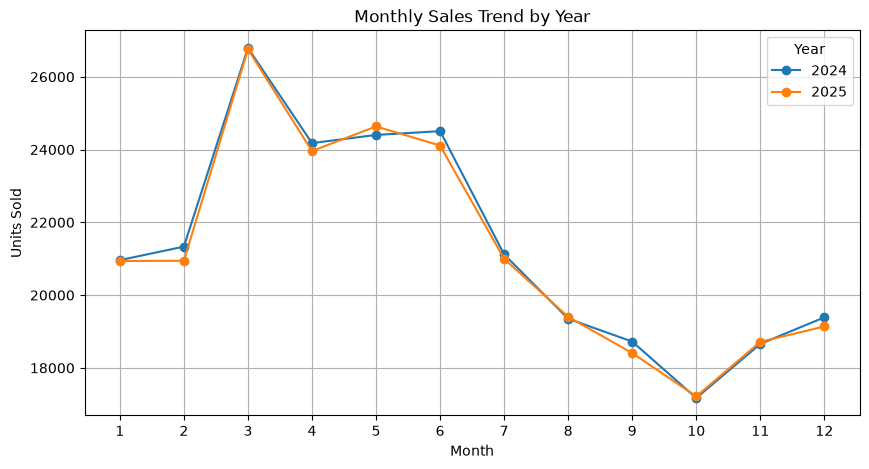

In [24]:
# Plotting monthly demand patterns
import matplotlib.pyplot as plt

monthly_comparison.plot(kind="line",marker="o",figsize=(10, 5))

plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

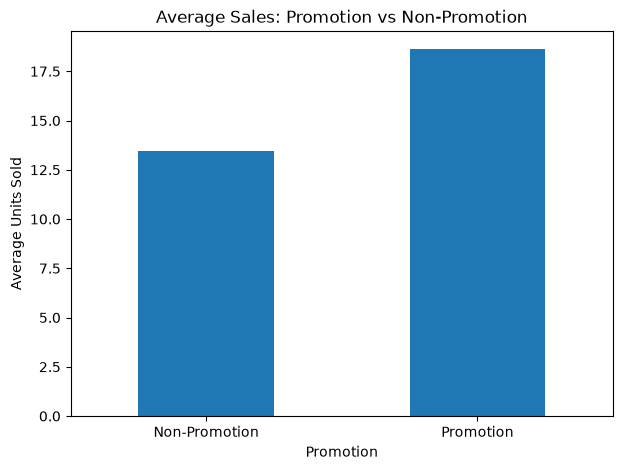

In [26]:
# Comparing average sales during promotion and non-promotion days
promotion_sales = (sales.groupby("Promotion")["Units_Sold"].mean())
promotion_sales.plot(kind="bar",figsize=(7, 5))
plt.title("Average Sales: Promotion vs Non-Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Units Sold")
plt.xticks([0, 1], ["Non-Promotion", "Promotion"], rotation=0)
plt.show()

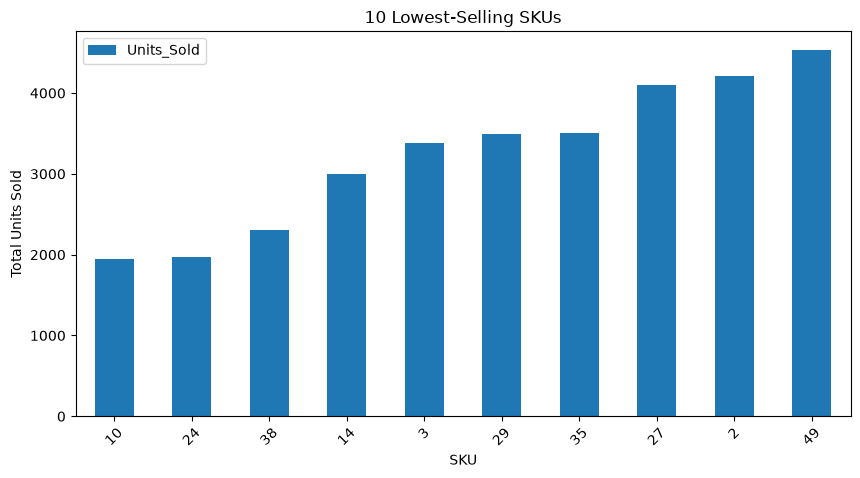

In [27]:
# Plotting the lowest-selling SKUs
Lowest_SKUs.plot(kind="bar",figsize=(10, 5))
plt.title("10 Lowest-Selling SKUs")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.show()

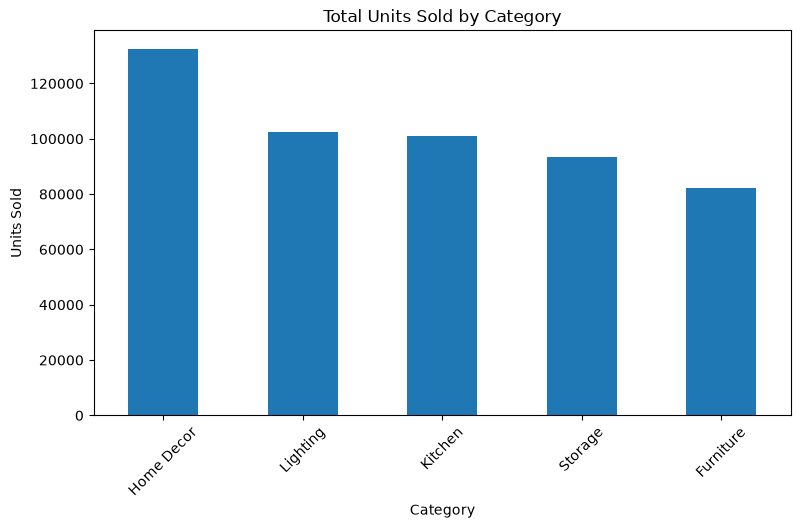

In [29]:
# Comparing total sales across categories
category_sales = (sales.merge(sku_master, on="SKU").groupby("Category")["Units_Sold"].sum().sort_values(ascending=False))

category_sales.plot(kind="bar",figsize=(9, 5))
plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

## EDA Summary

- Analyzed sales, SKU, promotion, category, and inventory data.
- **Home Decor** has the highest total unit sales.
- Promotion days show higher average sales (**18.61 vs 13.48 units**).
- Monthly demand patterns are broadly similar across 2024 and 2025, indicating recurring patterns.
- **SKU011** has the lowest average daily demand (**2.67 units/day**).
- **SKU011 and SKU028** have negative gross margins.
- Low-demand SKUs were further checked against inventory to identify potential stock risks.
- These findings will be used for **demand forecasting and stockout/overstock risk analysis**.